### Часть 1. Формализация задачи и первичный анализ данных

Нам предоставлена выборка объема $n = 15$ наблюдений по автомобилям ВАЗ 2110.
Задана следующая эконометрическая модель множественной линейной регрессии:
$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \varepsilon_i$$

Где:
* $y_i$ — стоимость $i$-го автомобиля.
* $x_{1i}$ — возраст $i$-го автомобиля.
* $x_{2i}$ — пробег $i$-го автомобиля.
* $\beta_j$ — неизвестные параметры генеральной совокупности.
* $\varepsilon_i$ — случайная ошибка (возмущение), удовлетворяющая условиям теоремы Гаусса-Маркова: $\mathbb{E}(\varepsilon_i) = 0$, $Var(\varepsilon_i) = \sigma^2$ (гомоскедастичность), $Cov(\varepsilon_i, \varepsilon_j) = 0$ при $i \neq j$ (отсутствие автокорреляции).

Первым шагом необходимо провести разведочный анализ данных (EDA), включающий расчет описательных статистик, оценку формы распределений с помощью гистограмм и анализ матрицы парных корреляций.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Загрузка данных (Вариант 11, ВАЗ 2110)
data = {
    'y': [175, 146, 120, 220, 172, 170, 190, 80, 143, 167, 150, 195, 131, 175, 150],
    'x1': [5, 8, 10, 4, 5, 7, 4, 10, 8, 6, 7, 4, 8, 4, 9],
    'x2': [70, 110, 175, 62, 84, 77, 83, 65, 120, 88, 89, 83, 108, 110, 90]
}
df = pd.DataFrame(data)

# Расчет основных статистических показателей
desc_stats = df.describe().T
desc_stats['variance'] = df.var()

print("--- Основные статистические показатели ---")
display(desc_stats[['count', 'mean', 'std', 'variance', 'min', 'max']])

--- Основные статистические показатели ---


,count,mean,std,variance,min,max
y,15.0,158.933333,33.781793,1141.209524,80.0,220.0
x1,15.0,6.600000,2.197401,4.828571,4.0,10.0
x2,15.0,94.266667,28.148755,792.352381,62.0,175.0


### Анализ мультиколлинеарности и распределения

Для оценки наличия строгой линейной зависимости между независимыми факторами (что приводит к вырожденности матрицы $X^T X$ и невозможности получения оценок МНК) строится корреляционная матрица:
$$R = \begin{pmatrix} 1 & r_{x_1x_2} \\ r_{x_2x_1} & 1 \end{pmatrix}$$
где $r_{x_1x_2}$ — выборочный коэффициент корреляции Пирсона. Высокая корреляция ($|r| > 0.8$) сигнализирует о мультиколлинеарности."


--- Корреляционная матрица независимых переменных (x1, x2) ---


,x1,x2
x1,1.000000,0.454526
x2,0.454526,1.000000


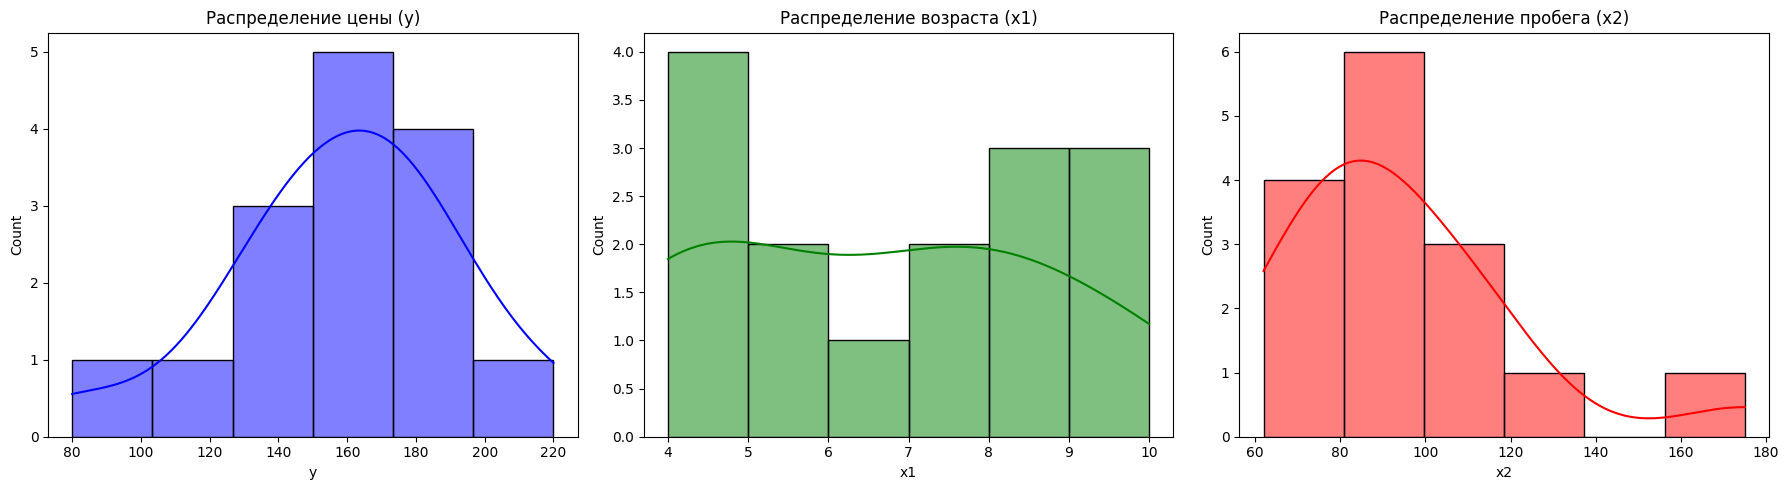

In [ ]:
# Построение корреляционной матрицы
corr_matrix = df[['x1', 'x2']].corr()
print("\n--- Корреляционная матрица независимых переменных (x1, x2) ---")
display(corr_matrix)

# Визуализация данных (гистограммы)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['y'], kde=True, ax=axes[0], color='blue', bins=6)
axes[0].set_title('Распределение цены (y)')

sns.histplot(df['x1'], kde=True, ax=axes[1], color='green', bins=6)
axes[1].set_title('Распределение возраста (x1)')

sns.histplot(df['x2'], kde=True, ax=axes[2], color='red', bins=6)
axes[2].set_title('Распределение пробега (x2)')

plt.tight_layout()
plt.show()

### Часть 2. Оценка параметров множественной регрессии

Оценки вектора параметров $\hat{\beta}$ находятся методом наименьших квадратов (МНК), минимизирующим сумму квадратов остатков $RSS = e^T e = (Y - X\hat{\beta})^T (Y - X\hat{\beta}) \rightarrow \min$.
Аналитическое решение в матричной форме имеет вид:
$$\hat{\beta} = (X^T X)^{-1} X^T Y$$
Где $X$ — матрица плана (с добавлением столбца единиц для оценки свободного члена $\beta_0$), $Y$ — вектор-столбец результативной переменной.

In [3]:
# Подготовка матрицы плана X и вектора Y
X = df[['x1', 'x2']]
X_with_const = sm.add_constant(X) # Добавляем столбец единиц
Y = df['y']

# Построение модели МНК (OLS)
model = sm.OLS(Y, X_with_const)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     23.64
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           6.88e-05
Time:                        11:41:38   Log-Likelihood:                -61.586
No. Observations:                  15   AIC:                             129.2
Df Residuals:                      12   BIC:                             131.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        246.8451     16.945     14.567      0.0

### Часть 3. Статистическая значимость модели и параметров

#### 1. Значимость отдельных параметров ($t$-критерий Стьюдента)
Мы проверяем нулевую гипотезу о равенстве коэффициентов нулю: $H_0: \beta_j = 0$ против альтернативной $H_1: \beta_j \neq 0$. 
Наблюдаемое значение t-статистики рассчитывается как:
$$t_{obs} = \frac{\hat{\beta}_j}{S_{\hat{\beta}_j}}$$
Где $S_{\hat{\beta}_j}$ — стандартная ошибка коэффициента. 
При уровне значимости $\alpha = 0.05$ и числе степеней свободы $df = n - k - 1 = 15 - 2 - 1 = 12$, критическое значение $t_{crit} \approx 2.179$. Если $|t_{obs}| > t_{crit}$, гипотеза $H_0$ отвергается, и фактор признается статистически значимым.

#### 2. Адекватность модели в целом ($F$-критерий Фишера)
Проверяется гипотеза о совместной незначимости всех факторов: $H_0: \beta_1 = \beta_2 = 0$[cite: 8].
Наблюдаемое значение статистики:
$$F_{obs} = \frac{R^2 / k}{(1 - R^2) / (n - k - 1)}$$
Где $R^2$ — коэффициент детерминации, $k = 2$ — количество факторов.
Расчетное значение сравнивается с $F_{crit}$ при степенях свободы $v_1 = k = 2$ и $v_2 = n - k - 1 = 12$. Для $\alpha = 0.05$ табличное значение $F_{crit} \approx 3.89$.

In [4]:
# Извлечение статистик для формального вывода
alpha = 0.05
n = len(df)
k = 2
df_resid = n - k - 1

# t-статистика
t_crit = stats.t.ppf(1 - alpha/2, df_resid)
t_obs_x1 = results.tvalues['x1']
t_obs_x2 = results.tvalues['x2']

# F-статистика
f_crit = stats.f.ppf(1 - alpha, k, df_resid)
f_obs = results.fvalue

print("--- Проверка значимости параметров (t-критерий) ---")
print(f"Критическое значение t-статистики: {t_crit:.4f}")
print(f"t-стат для x1 (возраст): {t_obs_x1:.4f} (p-value: {results.pvalues['x1']:.4f})")
print(f"t-стат для x2 (пробег): {t_obs_x2:.4f} (p-value: {results.pvalues['x2']:.4f})")

print("\n--- Проверка значимости уравнения в целом (F-критерий) ---")
print(f"Критическое значение F-статистики: {f_crit:.4f}")
print(f"Наблюдаемое значение F-статистики: {f_obs:.4f} (p-value: {results.f_pvalue:.4e})")

--- Проверка значимости параметров (t-критерий) ---
Критическое значение t-статистики: 2.1788
t-стат для x1 (возраст): -6.2422 (p-value: 0.0000)
t-стат для x2 (пробег): 0.2695 (p-value: 0.7921)

--- Проверка значимости уравнения в целом (F-критерий) ---
Критическое значение F-статистики: 3.8853
Наблюдаемое значение F-статистики: 23.6379 (p-value: 6.8836e-05)


### Часть 4. Итоговые выводы по результатам регрессионного анализа

На основании проведенных статистических тестов можно сделать следующие эконометрические выводы:

**1. Оценка индивидуальной значимости параметров ($t$-критерий Стьюдента):**
* Для фактора возраста автомобиля ($x_1$) расчетное значение статистики составило $|t_{obs}| = |-6.2422|$, что значительно превышает критическое значение $t_{crit} = 2.1788$ ($p < 0.001$). Нулевая гипотеза отвергается: **возраст оказывает статистически значимое влияние** на стоимость автомобиля.
* Для фактора пробега ($x_2$) расчетное значение составило $t_{obs} = 0.2695$, что меньше $t_{crit}$ ($p = 0.7921 > 0.05$). Нет оснований отвергнуть нулевую гипотезу ($H_0: \beta_2 = 0$). В присутствии фактора возраста, **влияние пробега признается статистически незначимым**.

**2. Оценка значимости уравнения в целом ($F$-критерий Фишера):**
Наблюдаемое значение критерия $F_{obs} = 23.6379$ многократно превосходит табличное критическое значение $F_{crit} = 3.8853$. Вероятность ошибки первого рода крайне мала ($p\text{-value} \approx 6.88 \times 10^{-5}$). Следовательно, основная гипотеза о совместной незначимости факторов уверенно отвергается. **Построенное уравнение регрессии в целом статистически значимо и адекватно описывает исходные данные**.

**3. Рекомендации по оптимизации модели:**
Возникла классическая ситуация: модель в целом значима, но один из факторов избыточен. В данной выборке переменная возраста ($x_1$) обладает настолько сильной объясняющей способностью, что добавление информации о пробеге ($x_2$) не дает статистически значимого улучшения прогноза цены. 
В целях улучшения спецификации модели и сохранения степеней свободы, **рекомендуется редуцировать модель множественной регрессии до парной**, исключив фактор $x_2$, и исследовать зависимость стоимости автомобилей исключительно от их возраста: $y = f(x_1)$.